# Clustering mixed-type tabular data with `forest_clustering`

### An end-to-end tutorial on the UCI **Adult** census dataset

This notebook is a hands-on walkthrough of the `forest_clustering` library applied to the
full **Adult** dataset (48,842 rows, mixed numerical + categorical features). We will:

1. Load and explore the data.
2. Explain and build the **random-partition similarity embedding** the library is based on.
3. Cluster with the library's three paths — **KMeans** (centroid), **Louvain** and **Leiden**
   (graph community detection).
4. Inspect which large-`n` paths avoid a dense `n x n` distance matrix and where that
   claim does and does not apply.
5. **Compare against scikit-learn baselines** (KMeans, Gaussian Mixture, Agglomerative).
6. **Compare the library's own settings** against each other (bins, iterations, clusterer).

> **A note on evaluation.** Adult is a *classification* dataset; its `income` label
> (`<=50K` / `>50K`) is **not** a ground-truth clustering. We use it only as a weak external
> reference (ARI / NMI) -- modest scores are expected because income is one of *many* latent
> structures in the data. We therefore also report **silhouette** (internal cohesion) and
> qualitative cluster profiles. We use one fixed seed for runtime reasons; a real analysis
> should repeat seeds and test partition stability.


## 1. Setup and data loading

The schema is the [UCI Adult / Census Income dataset](https://archive.ics.uci.edu/dataset/2/adult). For a self-contained executable example we read a combined CSV mirror when no local `data/adult-all.csv` is present. Missing values are denoted by `?`; because `skipinitialspace=True` removes the preceding space, `na_values='?'` is the correct parser setting. We then keep missingness as an explicit categorical level.

In [1]:
import time, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score)
from scipy.sparse.csgraph import connected_components

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import forest_clustering as fcmod
from forest_clustering import ForestClusterer
print("forest_clustering version:", fcmod.__version__)
RNG = 0

forest_clustering version: 0.9.1


In [2]:
# The Adult dataset. A repository-local cache is used when present.
COLS = ["age","workclass","fnlwgt","education","education_num","marital_status",
        "occupation","relationship","race","sex","capital_gain","capital_loss",
        "hours_per_week","native_country","income"]
local_candidates = [
    PROJECT_ROOT / "data" / "adult-all.csv",
    PROJECT_ROOT / "adult-all.csv",
]
local_path = next((path for path in local_candidates if path.exists()), None)
source = local_path or "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
df = pd.read_csv(
    source, header=None, names=COLS, na_values="?", skipinitialspace=True
)

# Clean target to a binary label and drop it from the feature matrix.
df["income"] = df["income"].astype(str).str.contains(">50K").astype(int)
y = df["income"].values
X = df.drop(columns=["income"]).copy()
missing_before_fill = int(X.isna().sum().sum())
for c in X.select_dtypes("object").columns:
    X[c] = X[c].fillna("Missing")
print(f"Data source: {source}")
print(f"Missing categorical values represented explicitly: {missing_before_fill:,}")
print(f"Rows: {len(X):,}   Features: {X.shape[1]}   >50K rate: {y.mean():.3f}")
X.head()

Data source: https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv
Missing categorical values represented explicitly: 6,465
Rows: 48,842   Features: 14   >50K rate: 0.239


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### A quick look at the feature types

In [3]:
dtypes = X.dtypes.apply(
    lambda t: "numerical" if pd.api.types.is_numeric_dtype(t) else "categorical"
)
pd.DataFrame({"dtype": dtypes, "n_unique": X.nunique()})

,dtype,n_unique
age,numerical,74
workclass,categorical,9
fnlwgt,numerical,28523
education,categorical,16
education_num,numerical,16
marital_status,categorical,7
occupation,categorical,15
relationship,categorical,6
race,categorical,5
sex,categorical,2


The data is genuinely **mixed**: continuous columns like `age` and `hours_per_week`
alongside high-cardinality categoricals like `occupation` and `native_country`.
A key convenience of `forest_clustering` is that it consumes this DataFrame **directly** --
it detects column types internally, so no manual scaling or one-hot encoding is required.
The scikit-learn baselines below, by contrast, need explicit preprocessing.

## 2. The random-partition similarity embedding

`forest_clustering` does not cluster the raw features. Instead it builds an **embedding**:

- It runs `L = n_iterations` random partitions. Each iteration picks a random subset of
  features, bins them, and assigns every row a **cell id** -- an integer identifying which
  cell of that random partition the row fell into.
- The embedding is the `(n, L)` matrix of cell ids. Two rows are **similar** if they land in
  the *same cell* across many iterations -- i.e. their **Hamming distance** (fraction of
  differing iterations) is small.

This turns mixed-type data into an integer code on which Hamming co-membership distance is
defined. The ids are nominal: only equality within an iteration has meaning. For large graph
jobs, the library bands several embedding columns to propose approximate neighbour candidates;
that LSH-style step saves memory but can miss edges, so connectivity must be checked.

In [4]:
t0 = time.time()
fc = ForestClusterer(n_iterations=200, n_bins=4, n_clusters=2,
                     corr_threshold=None, random_state=RNG)
fc.fit(X)                      # builds the embedding and clusters with default KMeans
E = fc.embedding_
fc_time = time.time() - t0
print(f"Embedding shape: {E.shape}   built+clustered in {fc_time:.1f}s")
print("A few opaque cell-id rows (only equality within a column is meaningful):")
pd.DataFrame(E[:4, :8])

Embedding shape: (48842, 200)   built+clustered in 0.7s
A few opaque cell-id rows (only equality within a column is meaningful):


,0,1,2,3,4,5,6,7
0,4205274760157275,4205274760769280,4205274760153254,4205274760009846,4205274760746276,4205274760746466,4205274817133362,4205274817604421
1,4205274760157275,4205274763221030,4205274760755390,4205274761285609,4205274760746277,4205274760752962,4205274817603716,4205274817603590
2,4205274760157274,4205274818365618,4205274759966625,4205274818377863,4205274760752990,4205274760752903,4205274817133362,4205274817862497
3,4205274760157275,4205274763540620,4205274759966625,4205274818377863,4205274760751303,4205274760752962,4205274763532331,4205274760752902


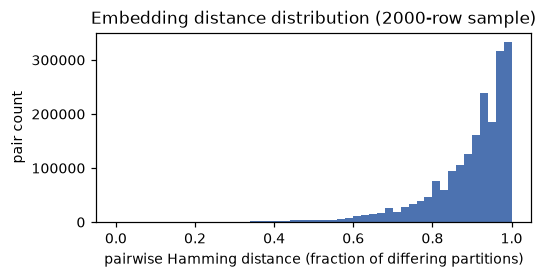

median pairwise distance: 0.925


In [5]:
# How concentrated are the pairwise Hamming distances? (sample for speed)
rng = np.random.default_rng(RNG)
idx = rng.choice(len(E), 2000, replace=False)
Es = E[idx]
H = (Es[:, None, :] != Es[None, :, :]).mean(2)          # fraction of differing iterations
tri = H[np.triu_indices(len(Es), k=1)]
plt.figure(figsize=(5, 2.6))
plt.hist(tri, bins=50, color="#4C72B0")
plt.xlabel("pairwise Hamming distance (fraction of differing partitions)")
plt.ylabel("pair count"); plt.title("Embedding distance distribution (2000-row sample)")
plt.tight_layout(); plt.show()
print(f"median pairwise distance: {np.median(tri):.3f}")

## 3. Clustering with the library

The library exposes three clustering paths, all on top of the same embedding:

| `clusterer` | family | how it scales on large `n` |
|---|---|---|
| an sklearn estimator (default `KMeans`) | centroid | sparse one-hot features; no pairwise matrix |
| `'louvain'` | graph community detection | exact dense path for small `n`, approximate sparse kNN path for large `n` |
| `'leiden'`  | graph community detection | same graph construction, optional `leidenalg` backend |

We already ran default KMeans with `k=2`, matching the number of income classes only for a
controlled weak-reference comparison. The graph methods instead infer a community count.
For the full Adult data we use `k=100` and `resolution=0.05`: a denser neighbourhood graph
and lower resolution than the defaults. These values were chosen exploratorily to reduce
fragmentation; they are not self-tuned and do not guarantee a small number of clusters.
Disconnected graph components cannot be merged by lowering resolution, so we inspect
connectivity before interpreting the communities.

In [6]:
def cluster_profile(labels, name):
    lab = labels[labels >= 0]
    sizes = pd.Series(lab).value_counts()
    return {"method": name,
            "n_clusters": len(np.unique(lab)),
            "median_cluster_size": round(float(sizes.median()), 1),
            "largest_%": round(100 * sizes.max() / len(labels), 1),
            "noise_%": round(100 * (labels < 0).mean(), 1)}

results_lib, timings = {}, {}
results_lib["forest+KMeans"] = fc.labels_
timings["forest+KMeans"] = fc_time

t0 = time.time()
fc_leiden = ForestClusterer(n_iterations=200, n_bins=4,
                            clusterer="leiden:k=100,resolution=0.05",
                            corr_threshold=None, random_state=RNG).fit(X)
timings["forest+Leiden"] = time.time() - t0
results_lib["forest+Leiden"] = fc_leiden.labels_

t0 = time.time()
fc_louvain = ForestClusterer(n_iterations=200, n_bins=4,
                             clusterer="louvain:k=100,resolution=0.05",
                             corr_threshold=None, random_state=RNG).fit(X)
timings["forest+Louvain"] = time.time() - t0
results_lib["forest+Louvain"] = fc_louvain.labels_

display(pd.DataFrame([cluster_profile(v, k) for k, v in results_lib.items()]).set_index("method"))

graph_knn = fc_leiden._clusterer_instance.knn_graph_.tocsr()
graph_undirected = graph_knn.maximum(graph_knn.T)
n_components, component_labels = connected_components(graph_undirected, directed=False)
component_sizes = np.bincount(component_labels)
print(f"Graph connected components: {n_components:,}")
print(f"Isolated observations: {(component_sizes == 1).sum():,}")
print(f"Non-trivial components: {(component_sizes > 1).sum():,}")
print(f"Largest component: {component_sizes.max():,} rows")

,n_clusters,median_cluster_size,largest_%,noise_%
method,,,,
forest+KMeans,2,24421.0,60.1,0.0
forest+Leiden,46,2.0,39.3,1.7
forest+Louvain,46,2.0,39.1,1.7


Graph connected components: 884
Isolated observations: 841
Non-trivial components: 43
Largest component: 33,564 rows


In [7]:
# What do the graph clusters "mean"? Profile the largest Leiden communities.
lab = fc_leiden.labels_
prof_df = X.copy(); prof_df["cluster"] = lab
top = pd.Series(lab[lab >= 0]).value_counts().head(4).index
rows = []
for c in top:
    sub = prof_df[prof_df["cluster"] == c]
    rows.append({"cluster": c, "size": len(sub),
                 "median_age": sub["age"].median(),
                 "median_hours": sub["hours_per_week"].median(),
                 "top_marital": sub["marital_status"].mode().iloc[0],
                 "top_occupation": sub["occupation"].mode().iloc[0],
                 ">50K_rate": round(float(y[lab == c].mean()), 3)})
pd.DataFrame(rows).set_index("cluster")

,size,median_age,median_hours,top_marital,top_occupation,>50K_rate
cluster,,,,,,
0,19184,30.0,40.0,Never-married,Other-service,0.056
1,9097,40.0,40.0,Married-civ-spouse,Craft-repair,0.320
2,3763,41.0,45.0,Married-civ-spouse,Exec-managerial,0.717
3,3704,44.0,40.0,Married-civ-spouse,Craft-repair,0.282


The table profiles only the four largest Leiden communities; it does not summarize the long
tail of small communities. Differences in `>50K` rate or modal categories are descriptive
associations, not proof that the clusters recover income, life stage, or occupation. In
particular, dozens of communities plus many disconnected components are a warning that this
graph partition is too fragmented for a simple audience-facing segmentation without further
graph construction work or explicit post-processing.

## 4. Memory behaviour of the paths used here

A naive "compute all pairwise distances, then cluster" approach needs an `n x n` matrix.
For Adult that is expensive. The default centroid path and the large-`n` graph path used
above avoid materializing it, but the library still exposes pairwise-distance APIs and uses
an exact dense graph path below its internal size threshold. Memory therefore depends on the
chosen downstream operation, not just on the estimator name.

In [8]:
from forest_clustering import weighted_onehot_features
n = len(E)
dense_gb = n * n * 4 / 1e9
phi = weighted_onehot_features(E, sparse_output=True)
phi_mb = (phi.data.nbytes + phi.indices.nbytes + phi.indptr.nbytes) / 1e6
G = graph_knn
g_mb = (G.data.nbytes + G.indices.nbytes + G.indptr.nbytes) / 1e6
embedding_mb = E.nbytes / 1e6
print(f"Dense n x n float32 distance matrix : {dense_gb:6.1f} GB   (not built here)")
print(f"Integer embedding                    : {embedding_mb:6.1f} MB")
print(f"Sparse one-hot features (centroid)  : {phi_mb:6.1f} MB   (nnz={phi.nnz:,})")
print(f"Actual k=100 LSH kNN graph          : {g_mb:6.1f} MB   (directed nnz={G.nnz:,})")
print(f"Dense / one-hot byte ratio          : {dense_gb * 1000 / phi_mb:6.0f}x")
print(f"Dense / graph byte ratio            : {dense_gb * 1000 / g_mb:6.0f}x")

Dense n x n float32 distance matrix :    9.5 GB   (not built here)
Integer embedding                    :   78.1 MB
Sparse one-hot features (centroid)  :  117.4 MB   (nnz=9,768,400)
Actual k=100 LSH kNN graph          :   22.7 MB   (directed nnz=3,743,722)
Dense / one-hot byte ratio          :     81x
Dense / graph byte ratio            :    421x


The printed ratios are the honest comparison for this run; they need not be three orders of
magnitude. The embedding, sparse one-hot matrix, and graph may also coexist during fitting, so
their individual sizes are not peak process memory. For graph string shortcuts, the current
implementation uses an exact dense Hamming matrix at `n <= 12,000` and LSH banding above that
threshold. LSH is memory-efficient but approximate, and the connectivity diagnostic above
shows why memory savings can affect clustering quality.

## 5. Comparison with scikit-learn baselines

We compare with standard scikit-learn clusterers after standardizing numeric columns and
one-hot encoding categoricals. Reported sklearn times include this shared preprocessing cost;
ForestClustering times include embedding construction. Timing a shared transform once and
adding it to each sklearn fit approximates the cost of running each pipeline independently.

ARI and NMI include every row, treating graph noise label `-1` as another returned label.
Silhouette excludes noise rows and is always computed in the same OHE + scaled space. That
space makes rows comparable but favours Euclidean baselines by construction. Agglomerative
clustering is evaluated on a 4,000-row subset and is explicitly marked non-comparable in scope.

In [9]:
num_cols = X.select_dtypes("number").columns.tolist()
cat_cols = X.select_dtypes("object").columns.tolist()
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
t0 = time.time()
Xsk = pre.fit_transform(X)
preprocess_time = time.time() - t0
print("sklearn design matrix:", Xsk.shape, type(Xsk).__name__)

sklearn design matrix: (48842, 108) csr_matrix


In [10]:
def evaluate(labels, X_for_sil, name, seconds, y_true=None, scope="full 48,842"):
    yt = y if y_true is None else y_true
    m = labels >= 0
    nlab = len(np.unique(labels[m]))
    ari = adjusted_rand_score(yt, labels) if len(labels) > 1 else np.nan
    nmi = normalized_mutual_info_score(yt, labels) if len(labels) > 1 else np.nan
    ss = min(4000, int(m.sum()))
    try:
        sil = silhouette_score(X_for_sil[m], labels[m], sample_size=ss, random_state=RNG) \
              if 1 < nlab < m.sum() else np.nan
    except Exception:
        sil = np.nan
    return {"method": name, "scope": scope, "clusters": nlab,
            "noise_%": 100 * (~m).mean(), "ARI": ari, "NMI": nmi,
            "silhouette": sil, "time_s": round(seconds, 3)}

rows = []
t0 = time.time(); skm = KMeans(n_clusters=2, n_init="auto", random_state=RNG).fit_predict(Xsk)
rows.append(evaluate(skm, Xsk, "sklearn KMeans (k=2)",
                     preprocess_time + time.time()-t0))

t0 = time.time()
gm = GaussianMixture(n_components=2, covariance_type="diag", random_state=RNG)
sgmm = gm.fit_predict(Xsk.toarray() if hasattr(Xsk, "toarray") else Xsk)
rows.append(evaluate(sgmm, Xsk, "sklearn GaussianMixture",
                     preprocess_time + time.time()-t0))

# Agglomerative is O(n^2): only feasible on a subsample -> a teaching point about scaling.
sub = rng.choice(n, 4000, replace=False)
Xsk_sub = (Xsk[sub].toarray() if hasattr(Xsk, "toarray") else Xsk[sub])
t0 = time.time(); sag = AgglomerativeClustering(n_clusters=2).fit_predict(Xsk_sub)
rows.append(evaluate(sag, Xsk_sub, "sklearn Agglomerative (4k subset)",
                     preprocess_time + time.time()-t0, y_true=y[sub], scope="4,000 subset"))

rows.append(evaluate(fc.labels_, Xsk, "forest+KMeans", timings["forest+KMeans"]))
rows.append(evaluate(fc_leiden.labels_, Xsk, "forest+Leiden", timings["forest+Leiden"]))
rows.append(evaluate(fc_louvain.labels_, Xsk, "forest+Louvain", timings["forest+Louvain"]))

comp = pd.DataFrame(rows).set_index("method")
comp.round(3)

,scope,clusters,noise_%,ARI,NMI,silhouette,time_s
method,,,,,,,
sklearn KMeans (k=2),"full 48,842",2,0.000,0.117,0.169,0.105,0.103
sklearn GaussianMixture,"full 48,842",2,0.000,-0.066,0.026,0.048,0.312
sklearn Agglomerative (4k subset),"4,000 subset",2,0.000,0.064,0.022,0.352,0.317
forest+KMeans,"full 48,842",2,0.000,0.182,0.129,0.103,0.744
forest+Leiden,"full 48,842",46,1.722,0.128,0.087,-0.058,14.553
forest+Louvain,"full 48,842",46,1.722,0.128,0.086,-0.059,29.267


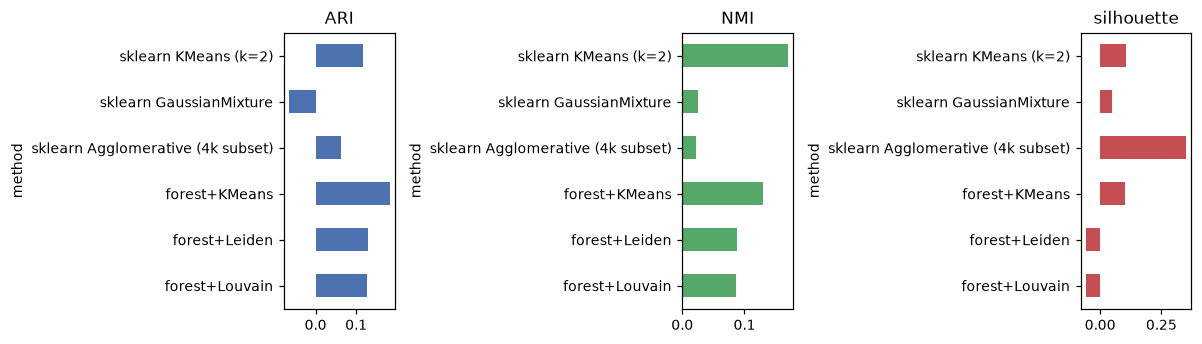

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, col, color in zip(ax, ["ARI", "NMI", "silhouette"], ["#4C72B0", "#55A868", "#C44E52"]):
    comp[col].plot.barh(ax=a, color=color)
    a.set_title(col); a.invert_yaxis()
plt.tight_layout(); plt.show()

**Reading the comparison.** There is no single winner. In this run forest+KMeans has higher
ARI against income than sklearn KMeans, while sklearn KMeans has higher NMI and a similar
common-space silhouette. Those metrics emphasize different aspects of a partition, and income
is only a weak reference. The 4,000-row agglomerative result has a much higher silhouette, but
its different sample prevents a direct full-data ranking.

The graph result is not good here: Louvain and Leiden return dozens of clusters and negative
common-space silhouette. They are faster/more memory-efficient than dense agglomerative
clustering on all 48k rows, but scalability does not compensate for a fragmented partition.
The defensible benefit shown by forest+KMeans is native mixed-type handling and competitive,
mixed metric results — not broad superiority over sklearn.

## 6. Comparing the library's own settings

We run a small one-seed grid over `n_bins` (`K`) and `n_iterations` (`L`). Each configuration
rebuilds its embedding, so runtime is end-to-end. This is an illustration of the tuning API,
not enough evidence to identify the most influential knobs or a production optimum. ARI/NMI
still use income only as a weak reference; silhouette uses the shared OHE + scaled space.

In [12]:
grid = []
for n_bins in [3, 4, 6]:
    for n_iter in [100, 200]:
        t0 = time.time()
        fck = ForestClusterer(n_iterations=n_iter, n_bins=n_bins, n_clusters=2,
                              corr_threshold=None, random_state=RNG).fit_predict(X)
        grid.append({"n_bins": n_bins, "n_iter": n_iter,
                     "ARI": adjusted_rand_score(y, fck),
                     "NMI": normalized_mutual_info_score(y, fck),
                     "silhouette": silhouette_score(
                         Xsk, fck, sample_size=4000, random_state=RNG
                     ),
                     "time_s": time.time() - t0})
grid_df = pd.DataFrame(grid)
grid_df.round(3)

,n_bins,n_iter,ARI,NMI,silhouette,time_s
0,3,100,0.182,0.163,0.101,0.586
1,3,200,0.183,0.129,0.101,0.876
2,4,100,0.183,0.128,0.101,0.548
3,4,200,0.182,0.129,0.103,0.857
4,6,100,0.183,0.127,0.100,0.550
5,6,200,0.183,0.128,0.101,0.891


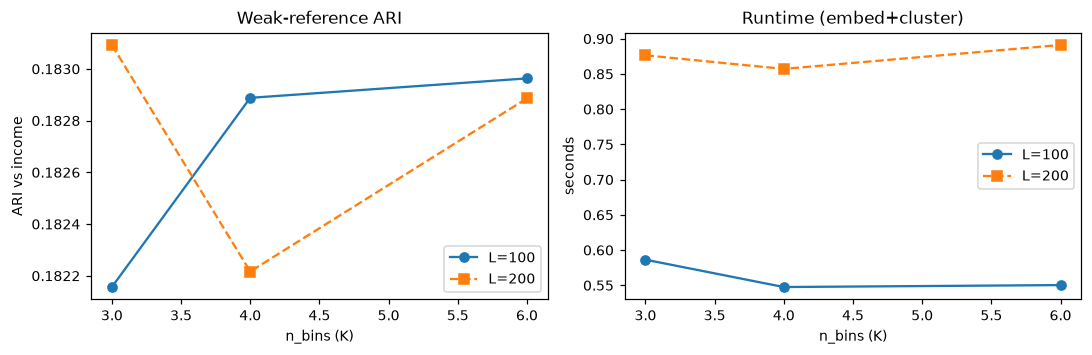

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
for n_iter, mk in zip([100, 200], ["o-", "s--"]):
    sub = grid_df[grid_df.n_iter == n_iter]
    ax[0].plot(sub.n_bins, sub.ARI, mk, label=f"L={n_iter}")
    ax[1].plot(sub.n_bins, sub.time_s, mk, label=f"L={n_iter}")
ax[0].set_xlabel("n_bins (K)"); ax[0].set_ylabel("ARI vs income"); ax[0].set_title("Weak-reference ARI"); ax[0].legend()
ax[1].set_xlabel("n_bins (K)"); ax[1].set_ylabel("seconds"); ax[1].set_title("Runtime (embed+cluster)"); ax[1].legend()
plt.tight_layout(); plt.show()

In [14]:
# Reuse the fitted models from section 3: all share K=4, L=200, and one seed.
clusterer_rows = [
    evaluate(labels, Xsk, name, timings[name])
    for name, labels in results_lib.items()
]
pd.DataFrame(clusterer_rows).set_index("method").round(3)

,scope,clusters,noise_%,ARI,NMI,silhouette,time_s
method,,,,,,,
forest+KMeans,"full 48,842",2,0.000,0.182,0.129,0.103,0.744
forest+Leiden,"full 48,842",46,1.722,0.128,0.087,-0.058,14.553
forest+Louvain,"full 48,842",46,1.722,0.128,0.086,-0.059,29.267


**Settings takeaways.**

- Across the small `K`/`L` grid, weak-reference metrics are nearly flat while runtime rises with
  `L`. This does not support claiming that more iterations improved quality in this run.
- One seed cannot establish stability. Repeat the entire fit and compare partitions pairwise
  before choosing a higher iteration budget.
- Leiden is faster than NetworkX Louvain here, but both operate on similarly disconnected LSH
  graphs and return similarly fragmented, low-silhouette partitions. Backend speed is not a
  quality recommendation.
- Increasing `k` can improve candidate-graph connectivity and lowering `resolution` often merges
  communities **within** components; neither can guarantee a desired count, and resolution cannot
  merge disconnected components.

## 7. Conclusions

- The library successfully builds a mixed-type random-partition embedding for all 48,842 rows,
  and its centroid and large-`n` graph paths avoid a dense pairwise matrix in this run.
- Forest+KMeans is the credible demonstration on Adult: it is easy to apply and has mixed but
  competitive results versus sklearn KMeans (better weak-reference ARI, worse NMI, similar
  common-space silhouette). That is not a general win.
- The chosen Louvain/Leiden configurations are **not good clusterings of Adult** for a simple
  segmentation: each produces 46 communities and common-space silhouette near `-0.06`. The LSH
  graph has 884 components: 841 isolated observations (reported as noise) and 43 non-trivial
  components. Those disconnected components impose a floor near the observed community count.
- Lowering resolution cannot repair disconnected components. Plausible next experiments are
  improving graph construction/recall, increasing connectivity with measured memory cost, or
  explicitly merging communities under a separately validated objective. None is automatic.
- The `K`/`L` grid is nearly flat on the weak reference and uses one seed, so it does not justify
  claims of predictable quality gains or self-tuning.

Use this notebook as an evaluation template: parse missing data correctly, declare the metric
space and sample scope, include preprocessing in timings, inspect graph connectivity, and report
when a scalable result is statistically or qualitatively poor.